In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

from rebin_utils import downsample
from spectral_lines import LINES, print_available_lines

#  H II region Data

In [3]:
print_available_lines()

Halpha
NII_6583
SII_6731
OIII_5007
ArIII_7136
SIII_9069


In [4]:
cfg = LINES["Halpha"]

plot_label = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
element = cfg.element
ion = cfg.ion
transition_id = cfg.transition_id

In [5]:
print(plot_label)
print(rest_wavelength)
print(element)
print(ion)
print(transition_id)

H$\alpha$
6562.8
H
H_I
H_I-6563


In [6]:
# Data from observations
bins        = 4

region     = 'M 42'
name_reg   = 'Orion'
reg_id     = 'M42'
inst       = 'MUSE'
inst_id    = 'MUSE'
type_obj   = 'H II region'

pix        = 0.2   # Instrument resolution [arcsec/pix]
dist       = 410 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60) # value in parsecs of each arcsec
s0         = (s0_*pc) / 2.355    # RMS seeing [parsecs]

#Since we are working with matrix data binning can be applied
#name_file    =  inst_id + '-' + reg_id + '-' + line_id 
name_file    =  transition_id
name_id      =  inst_id + '-' + reg_id + '-' + element + '-' + 'bin' + str(bins) + '_trim-ivsv'
print(name_file)
print(name_id)

H_I-6563
MUSE-M42-H-bin4_trim-ivsv


# Loading Files

In [7]:
from pipeline_config import OBSERVATIONS_DIR

flux_path    = OBSERVATIONS_DIR / f'linesum-{name_file}.fits'
radvel_path  = OBSERVATIONS_DIR / f'mean-{name_file}-patfixx.fits'

# Open files
flux    = fits.open(flux_path)
rad_vel = fits.open(radvel_path)

In [8]:
sb = flux[0].data.astype(float)
vv = rad_vel[0].data.astype(float)
#ss    = np.array(_data['ss'])

In [9]:
max_sb = sb.max()

In [10]:
hdul_mask = fits.open('fits_ready/mask_min.fits')
hdr_mask = hdul_mask[0].header
mask = hdul_mask['MASK'].data.astype(bool)

In [11]:
trim = (slice(25, 1400), slice(425, 1350))
trim

(slice(25, 1400, None), slice(425, 1350, None))

In [12]:
sb = sb[trim]
vv = vv[trim]
mask = mask[trim]

In [13]:
vv[np.isfinite(vv)]

array([12.28719265, 13.15747893, 10.68505335, ..., 14.48822999,
       12.60682682, 16.44961309])

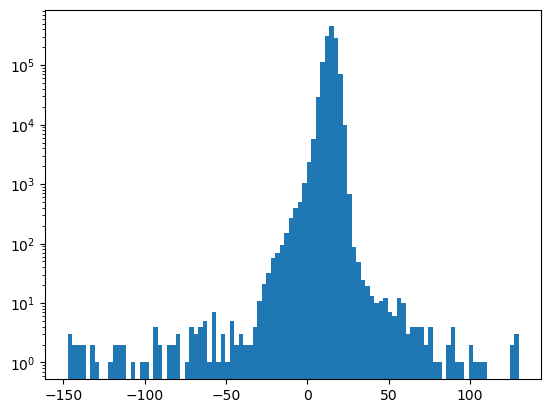

In [14]:
fig, ax = plt.subplots()
plt.hist(vv[np.isfinite(vv)& (np.abs(vv) < 150)] , bins=100)
ax.set_yscale("log")

Text(0.5, 0.8, 'H$\\alpha$')

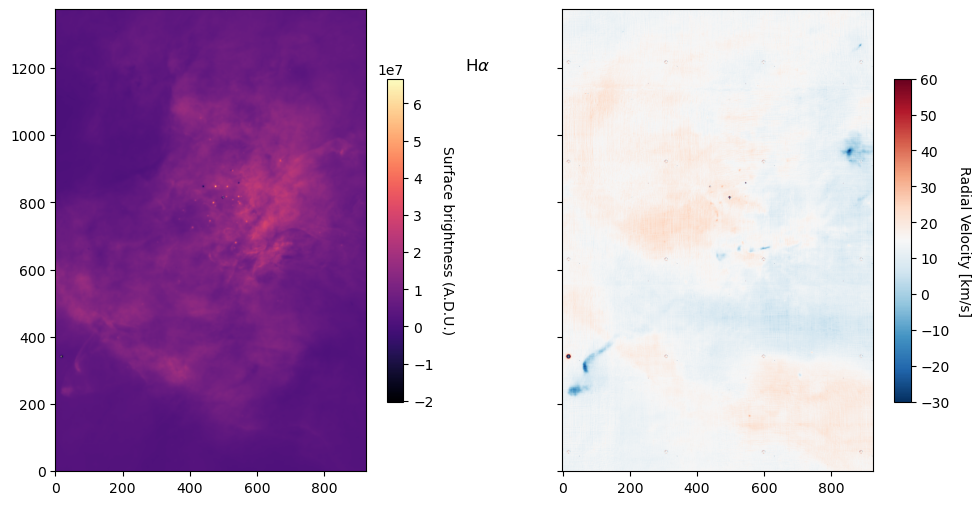

In [15]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, vmin=-30, vmax=60, **imshow_kwds)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

# Downsampling

In [16]:
prod_map  = sb * vv
sb_       = pd.notna(sb)
vv_       = pd.notna(vv)
mask_     = pd.notna(mask)
prod_map_ = sb_ * vv_

In [17]:
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [sb], sb_= downsample([sb], sb_, mingood=mingood)

for mingood in zip(mingoods):
 [prod_map], prod_map_= downsample([prod_map], prod_map_, mingood=mingood)

for mingood in zip(mingoods):
 [mask], mask_= downsample([mask], mask_, mingood=mingood)

# Binned vv map and boolean mask
vv = prod_map/sb
mask = mask.astype(bool)

# Masking 

In [18]:
m = ~np.isfinite(sb) | (sb < 0.0)
sb[m] = 0.0
#sb   /= sb.max()

In [19]:
#vv = np.where(mask, vv, np.nan)     
#sb = np.where(mask, sb, np.nan) 

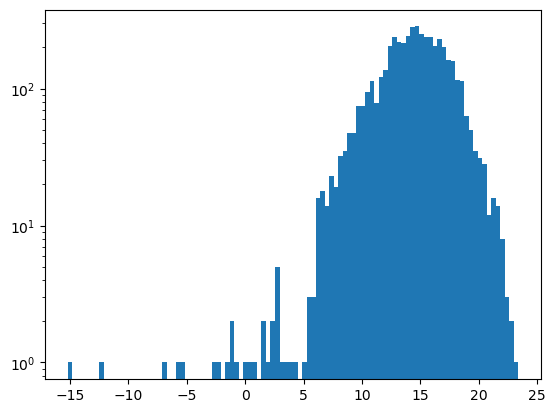

In [20]:
fig, ax = plt.subplots()
plt.hist(vv[np.isfinite(vv)& (np.abs(vv) < 150)] , bins=100)
ax.set_yscale("log")

Text(0.5, 0.8, 'H$\\alpha$')

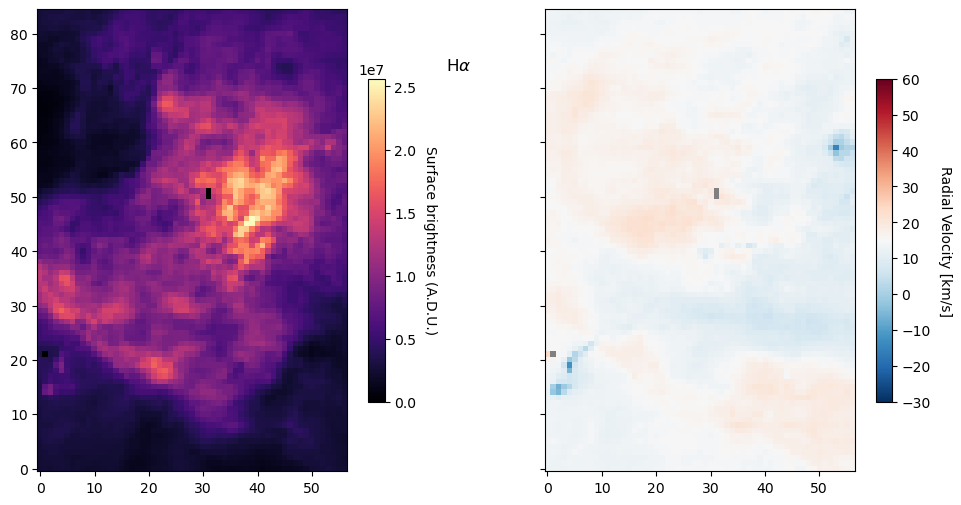

In [21]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, vmin=-30, vmax=60, **imshow_kwds)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [22]:
#df_sb  = pd.DataFrame(sb)
#df_sb= df_sb.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'I'})
#df_vv  = pd.DataFrame(vv)
#df_vv= df_vv.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'RV'})
#data = df_sb
#data['RV']= df_vv.RV
#data.describe()

In [23]:
#sns.pairplot(data, 
#             vars=["I","RV"], 
#             diag_kind='hist',  
#             plot_kws=dict(alpha=0.3, s=10, edgecolor='none'),
#             diag_kws=dict(bins=20),
#            )

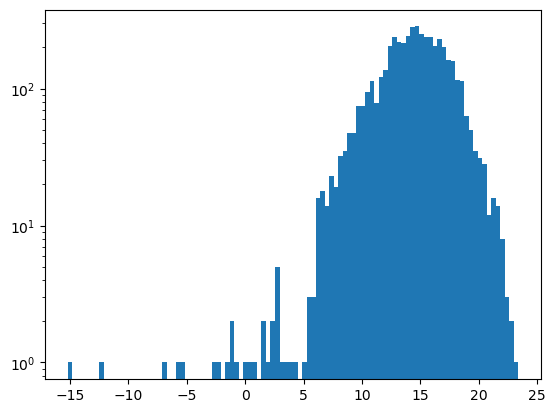

In [24]:
fig, ax = plt.subplots()
plt.hist(vv[np.isfinite(vv)& (np.abs(vv) < 50)] , bins=100)
ax.set_yscale("log")

In [25]:
mu    = np.nanmean(vv)
sigma = np.nanstd(vv)
n     = 10.0
#mask_vv = (vv > (mu - n*sigma)) & (vv < (mu + n*sigma))
mask_vv = (vv > 5) & (vv < 28)

In [26]:
sb_m = np.where(mask_vv, sb, np.nan)     
vv_m = np.where(mask_vv, vv, np.nan)     

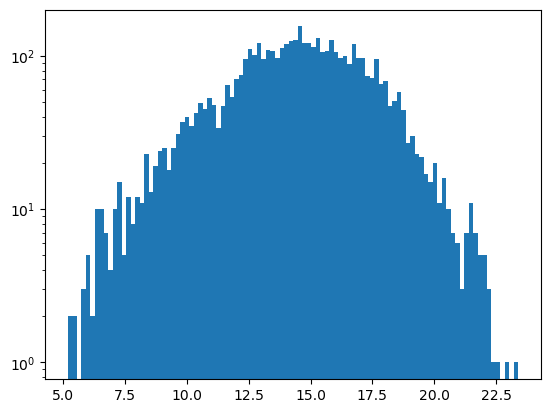

In [27]:
fig, ax = plt.subplots()
plt.hist(vv[np.isfinite(vv_m)& (np.abs(vv_m) < 150)] , bins=100)
ax.set_yscale("log")

Text(0.5, 0.8, 'H$\\alpha$')

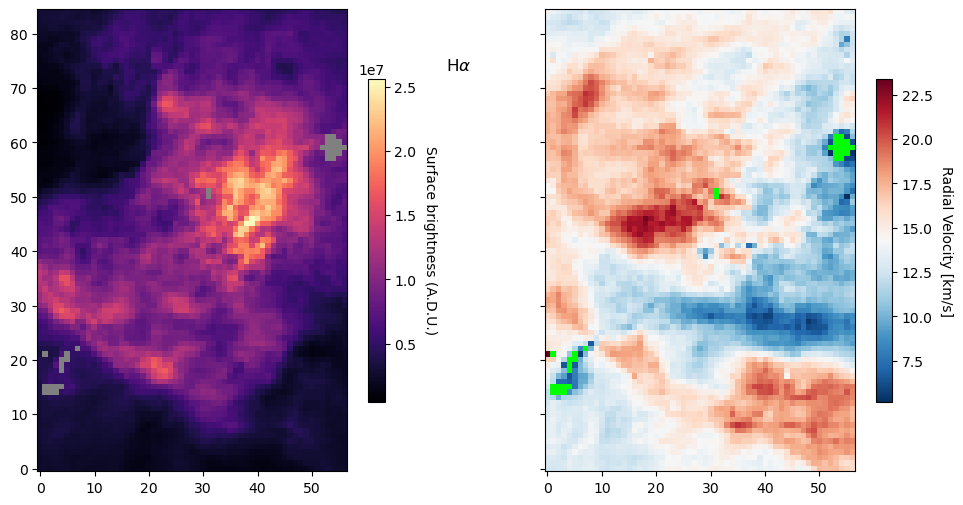

In [28]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m, **imshow_kwds)
im.cmap.set_bad(color='lime')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [29]:
#df_sb_m    = pd.DataFrame(sb_m)
#df_sb_m    = df_sb_m.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'I'})
#df_vv_m  = pd.DataFrame(vv_m)
#df_vv_m  = df_vv_m.stack().reset_index().rename(columns={'level_0':'X', 'level_1':'Y', 0:'RV'})
#data     = df_sb_m
#data['RV']= df_vv_m.RV
#data.describe()

In [30]:
#sns.pairplot(data, 
#             vars=["I","RV"], 
#             diag_kind='hist',  
#             plot_kws=dict(alpha=0.3, s=10, edgecolor='none'),
#             diag_kws=dict(bins=20),
#            )

V - Vmean map

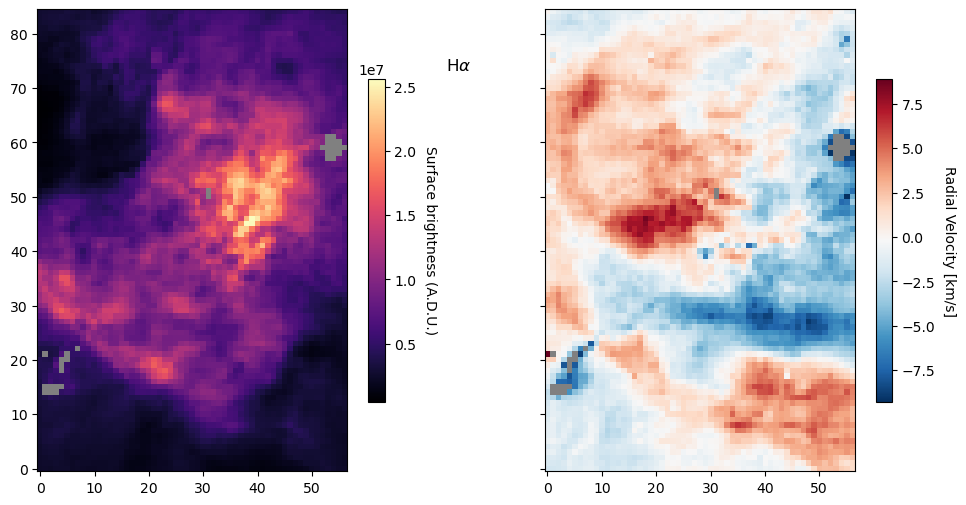

In [31]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m-np.nanmean(vv_m), **imshow_kwds)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
fig.suptitle(plot_label, y=0.8)

plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight') 

In [32]:
sb_m1 = np.where(np.isnan(sb_m), 0, sb_m)     
vv_m1 = np.where(np.isnan(vv_m), np.nanmean(vv_m), vv_m)  

Text(0.5, 0.8, 'H$\\alpha$')

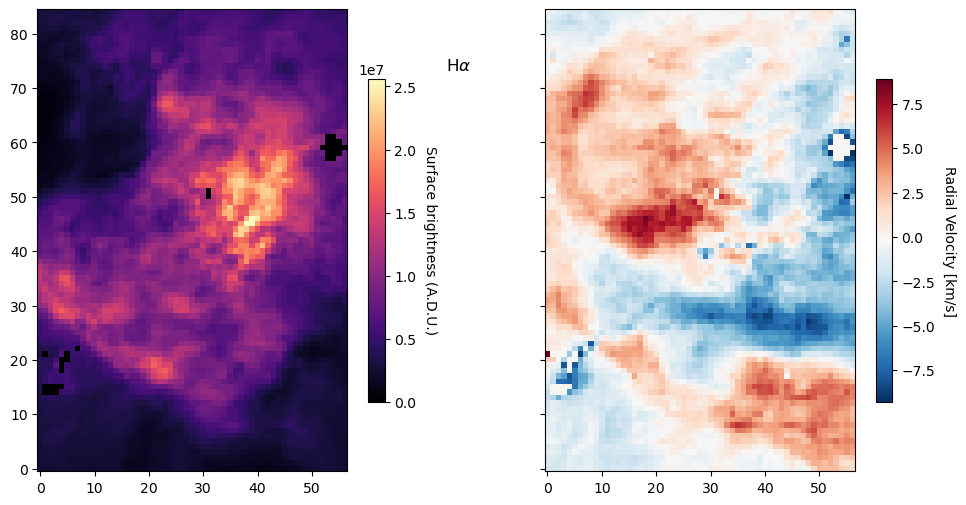

In [33]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m1-np.nanmean(vv_m1), **imshow_kwds)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(sb_m1, **imshow_kwds2)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [34]:
#fig, ax = plt.subplots()
#plt.hist(data["RV"] , bins=200)
#ax.set_yscale("log")

In [35]:
N = np.sqrt(vv_m1.shape[0] * vv_m1.shape[1]) * pix * pc
N

0.02767168529612918

In [36]:
sig = np.nanstd(vv_m1)
sig

2.890359449707639

Text(0.5, 0.8, 'H$\\alpha$')

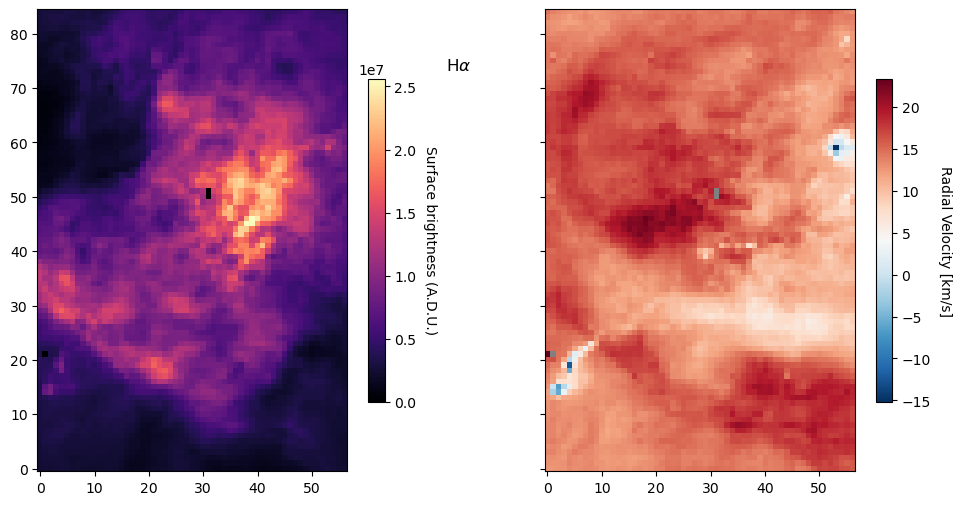

In [37]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, **imshow_kwds)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

# Export

In [38]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (plot_label, "Emission line name")
primary.header["LINE_ID"]    = (transition_id, "Emission line identifier")
primary.header["L_REST"]     = (rest_wavelength, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N* (2**bins), "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix* (2**bins), "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [39]:
hdu_m0 = fits.ImageHDU(data=sb_m1,  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m1,  name='MOM1')
#hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')
#hdu_mk = fits.ImageHDU(data=(mask & mask_vv).astype(np.uint8) ,  name='MASK')

In [41]:
hdul = fits.HDUList([primary, hdu_m0, hdu_m1])
hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

In [42]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()
    
hdr = hdul[0].header
print(hdr)


Filename: fits_ready/MUSE-M42-H-bin4_trim-ivsv.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (57, 85)   float64   
  2  MOM1          1 ImageHDU         8   (57, 85)   float64   
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'H_I-6563'           / Fits file name                                 NAME_ID = 'MUSE-M42-H-bin4_trim-ivsv' / pipeline identifier                     REG     = 'M 42    '           / Region catalog name                            NAME_REG= 'Orion   '           / Region name                                    REG_ID  = 'M42     '           / Region identifier                 